# SET-UP

## Imports

In [1]:
%matplotlib widget

import lmfit
import matplotlib.pyplot as plt
from multiprocessing import Pool
import numpy as np
import pandas as pd
# from ocelot.optics.wave import RadiationField, imitate_sase_dfl
import scipy.constants as spconst
from tqdm.notebook import tqdm
import xarray as xr

import fitting_tools as dfit
from TASsello import convert_E_to_I
from TASsello.constants import cm, um, fs
from XRR.XRR_self_consistent import Sample, ParrattSimulator

## Inputs

In [2]:
def nm2eV(nm):
    return 1e9 * spconst.h * spconst.c / nm / spconst.eV

# Define Gaussian function
def gaussian_3d(x, y, t, FWHM_x, FWHM_y=None):
    """Generate 3D Gaussian function. The time profile is fixed with mu=30 and FWHM=15."""
    sigma_x = FWHM_x / 2.3548
    sigma_t = 15 / 2.3548
    t0 = 30
    if FWHM_y is None:
        sigma_y = sigma_x
    else:
        sigma_y = FWHM_y / 2.3548
    return np.exp(-( x**2 / (2 * sigma_x**2) + y**2 / (2 * sigma_y**2) + (t-t0)**2 / (2 * sigma_t**2) ))

In [3]:
Sample.dirname_params = './sources/XRR/fit_parameters/tight_fit/'

In [4]:
samplename = 'M-220629B1_D006825_with_SiO2'
theta_1 = 63.79689844922461
# theta_2 = 67.04018341701854

alpha = np.linspace(32.3, 32.44, 100)

# SIMULATION
## Parameters

In [5]:
ph_en = np.linspace(920, 940, 100)

focus = 20 #um
t_FWHM = 15 #fs

In [6]:
xspan = 4*focus #um
yspan = xspan
tspan = 60 #fs

xgrid = xspan + 1
ygrid = xgrid
tgrid = 60

x = np.linspace(-0.5*xspan, 0.5*xspan, xgrid)
y = np.linspace(-0.5*yspan, 0.5*yspan, ygrid)
t = np.linspace(0, tspan, tgrid)

dx = x[1]-x[0]
dy = y[1]-y[0]
dt = t[1]-t[0]

In [7]:
def unique_points(xgrid):
    idxs = [i for i in range(int((xgrid-1)/2 + 1))]
    iy = int((xgrid-1)/2)

    weights = np.abs(2 * np.pi * x[idxs]) + 1
    weights = weights / np.sum(weights)
    
    grid_points = [(w, ix, iy, it) for (ix, w) in zip(idxs, weights) for it in range(tgrid)]
    
    return grid_points

# Find the unique grid points and how many are they
grid_points = unique_points(xgrid)

In [8]:
def field_norm_3d(field_yxt):
    norm_yx = np.trapezoid(field_yxt, t, axis=2) * fs
    norm_y = np.trapezoid(norm_yx, x, axis=1) * um/cm
    norm = np.trapezoid(norm_y, y, axis=0) * um/cm
    return norm

In [9]:
exports_name = [
    'M_220706E1_Z_0.3_',
    'M_220706E1_Z_10_',
    'M_220706E1_Z_25_',
    'M_220706E1_Z_50_',
    'M_220706E1_Z_100_',    
]

In [10]:
pulse_energies = [0.1e-6, 9.2e-6, 19.8e-6, 66.1e-6, 144.6e-6]
reduce_by = 0.43

pulse_energies = [pe*reduce_by for pe in pulse_energies]

In [11]:
pulse_energies

[4.2999999999999995e-08,
 3.956e-06,
 8.514e-06,
 2.8422999999999995e-05,
 6.2178e-05]

Pulse intensity: 6.86e+12 W/cm^2


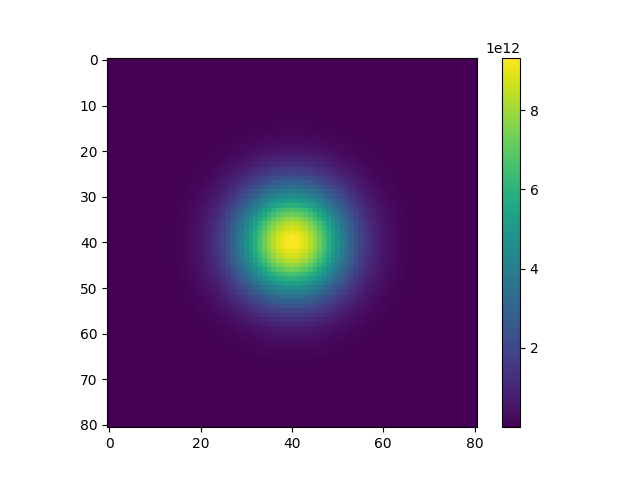

  0%|          | 0/2460 [00:00<?, ?it/s]

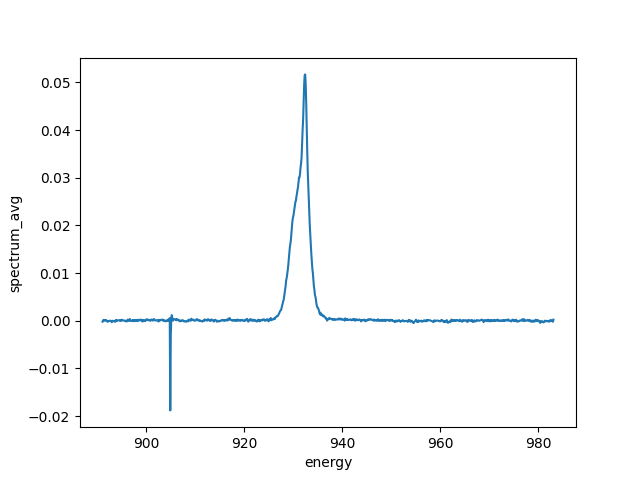

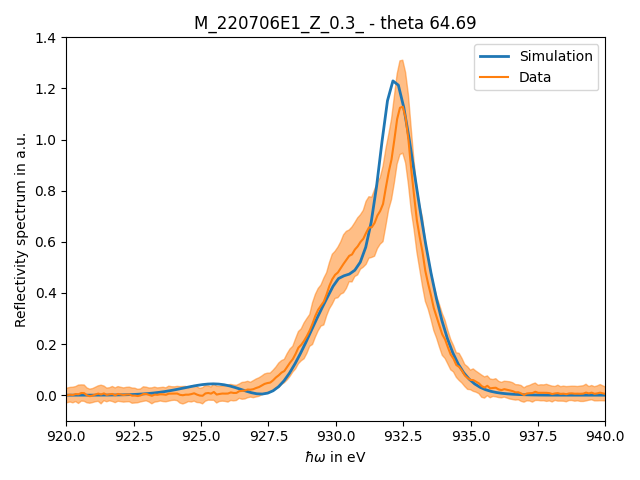

Pulse intensity: 6.31e+14 W/cm^2


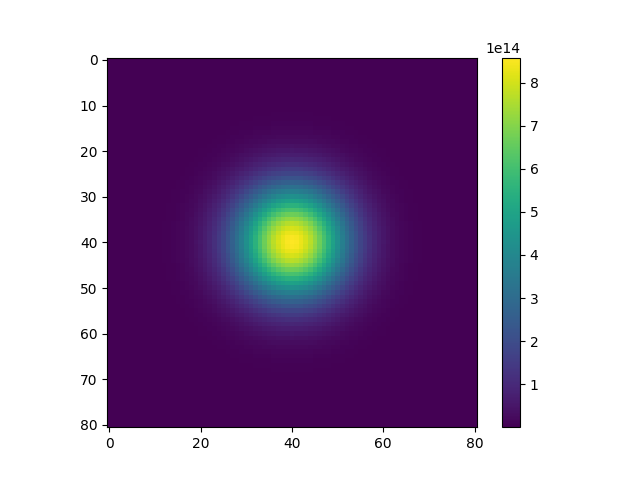

  0%|          | 0/2460 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
for ie, E_pulse_J in enumerate(pulse_energies): #J
    # if ie in [1,2,3,4]:
    #     print(f'Skipping: {E_pulse_J} uJ')
    #     continue
    
    I_pulse = convert_E_to_I(E_pulse_J, focus/2, t_FWHM)
    print(f'Pulse intensity: {I_pulse:.2e} W/cm^2')
    
    # Create 2D/3D mesh grid
    X, Y, T = np.meshgrid(x, y, t)
    
    # Compute the 3D Gaussian used for weighting
    field_yxt = gaussian_3d(X, Y, T, focus)
    field_yxt_norm = field_yxt / field_norm_3d(field_yxt)
    field_yxt = field_yxt_norm * E_pulse_J

    plt.figure()
    plt.imshow(np.sum(field_yxt, axis=2))
    plt.colorbar()
    plt.show()

    params = lmfit.Parameters()
    params.add('A', 1)
    params.add('mu', 929.3)
    params.add('sigma', 1.95)
    params.add('offset', 0)
    ph_dens = dfit.gaussian_model(params, ph_en)
    ph_dens = ph_dens / np.trapezoid(ph_dens, ph_en)

    # PARRATT 
    sample = Sample(samplename)
    simulator = ParrattSimulator(sample, alpha=alpha, wls_eV=ph_en)
    def simulate(grid_point):
        w, ix, iy, it = grid_point
    
        simulator.sample.f1f2Simulator.set_sim_params(np.sum(field_yxt, axis=2)[iy,ix], t[it])
        simulator.sample.set_f1_f2_Cu()
    
        f1, f2 = simulator.sample.f1_Cu, simulator.sample.f2_Cu
        
        R = simulator.simulate()
        
        return {'x': x[ix], 'y': y[iy], 't': t[it], 'grid_weights': w,
                'R_sim': R,
                'field_norm': field_yxt_norm[iy,ix,it], 'spectrum_norm': ph_dens,
                'f1': f1, 'f2': f2}

    with Pool(processes=8) as pool:
        results = list(tqdm(pool.imap_unordered(simulate, grid_points), total=len(grid_points)))

    # Expand dictionaries to include energy index
    expanded_data = []
    for d in results:
        for i, e in enumerate(ph_en):
            for j, a in enumerate(simulator.alpha):
                expanded_data.append({'x': d['x'], 'y': d['y'], 't': d['t'],
                                      'grid_weights': d['grid_weights'],
                                      'energy': e, 'alpha': a,
                                      'R_sim': d['R_sim'][j,i],
                                      'spectrum_norm': d['spectrum_norm'][i], 'field_norm': d['field_norm'],
                                      'f1': d['f1'][i], 'f2': d['f2'][i]
                                     })
    
    # Convert to DataFrame
    df = pd.DataFrame(expanded_data)
    
    # Convert to xarray Dataset
    ds = df.set_index(['x', 'y', 't', 'energy', 'alpha']).to_xarray()

    del results, expanded_data, df

    # Collapse variables without energy and alpha dimension
    ds['field_norm'] = ds['field_norm'].mean(dim=['energy', 'alpha'])
    ds['spectrum_norm'] = ds['spectrum_norm'].mean(dim=['x', 'y', 't', 'alpha'])
    ds['grid_weights'] = ds['grid_weights'].mean(dim=['energy', 'alpha'])
    ds['f1'] = ds['f1'].mean('alpha')
    ds['f2'] = ds['f2'].mean('alpha')

    # Save ds to HDF5
    # ds.to_netcdf(f'imgs/XFEL_forward_many_angles_reduced_0p43_tight_alpha/{focus}um/h5/{1e6*E_pulse_J:.3f}.h5', engine='h5netcdf')

    # Multiply by incoming spectrum and weights
    ds['R'] = ds['spectrum_norm'] * ds['R_sim'] * ds['grid_weights']
    
    # Create weighted curves by field intensity
    ds['Rw'] = ds['R'] * ds['field_norm']

    # plt.figure()
    # ds['Rw'].sum(dim=['x', 'y']).plot()
    # plt.show()

    sampleident = exports_name[ie]
    data = xr.open_dataset(f'XFEL_exports/{sampleident}.h5', engine="h5netcdf")

    plt.figure()
    data['spectrum_avg'].plot()
    plt.show()

    R_full = ds['Rw'].sum(dim=['x', 'y', 't'])

    # Normalization: re-scale the value at the Ledge to 1
    hw_L3 = 932.7
    
    simidx = np.argmin(np.abs(ph_en - hw_L3))
    dataidx = np.argmin(np.abs(data['energy'].values - hw_L3))
    
    R_full_norm = R_full / R_full[simidx]
    
    data['spectrum_avg_norm'] = data['spectrum_avg'] / data['spectrum_avg'].sel(energy=hw_L3, method='nearest')

    # Find optimal angle
    data_interp = np.interp(R_full_norm['energy'].values,
                            data['spectrum_avg_norm']['energy'].values,
                            data['spectrum_avg_norm'].values)
    resids = []
    for ia, a in enumerate(R_full_norm['alpha']):
        resids.append(np.sum(np.abs(R_full_norm.isel(alpha=ia).values - data_interp)**2))
    idx = np.argmin(resids)

    # Comparison plot
    plt.figure()
    
    plt.plot(R_full_norm['energy'], R_full_norm.isel(alpha=idx), linewidth=2, label='Simulation')
    
    data['spectrum_avg_norm'].plot(label = 'Data')
    plt.fill_between(data['energy'],
                     (data['spectrum_avg'] + data['spectrum_std']) / data['spectrum_avg'].sel(energy=hw_L3, method='nearest'),
                     (data['spectrum_avg'] - data['spectrum_std']) / data['spectrum_avg'].sel(energy=hw_L3, method='nearest'),
                     color = 'C1', alpha = 0.5
                    )
    
    
    plt.xlabel(r'$ \hbar \omega $ in eV')
    plt.ylabel(r'Reflectivity spectrum in a.u.')
    
    plt.legend()
    
    plt.xlim(920, 940)
    plt.ylim(-0.1)
    
    plt.title(f'{sampleident} - theta {2*R_full_norm.alpha[idx]:.2f}')
    
    plt.tight_layout()
    plt.show()
    
    # plt.savefig(f'imgs/XFEL_forward_many_angles_reduced_0p43_tight_alpha/{focus}um/edge_{1e6*E_pulse_J:.3f}.png', bbox_inches='tight')

    del ds